#### Process NDPI slides

In [ ]:
import os
import sys
from glob import glob
sys.path.append('../src')
from biliary_seg.pipelines.preprocess_slides import parse_slide


slide_paths = glob('..\\data\\raw\\slides\\*')

for slide_path in slide_paths:
    geo_path = slide_path.replace('slides', 'geojson').replace('.ndpi', '.geojson')
    if not os.path.exists(geo_path):
        print(f'GeoJSON file not found for {slide_path}. Skipping.')
        continue
    
    slide_id = slide_path.split('\\')[-1].replace('_', ' ').split(' ')[0]
    print(f'Processing slide: {slide_id}')
    parse_slide(
        slide_id=slide_id,
        slide_path=slide_path,
        annotation_path=geo_path,
        output_dir='..\\data\\processed',
        downsample_factor=8,
        annotation_roi_tag='Field of Annotation'
        
    )

#### Display Processed Slide

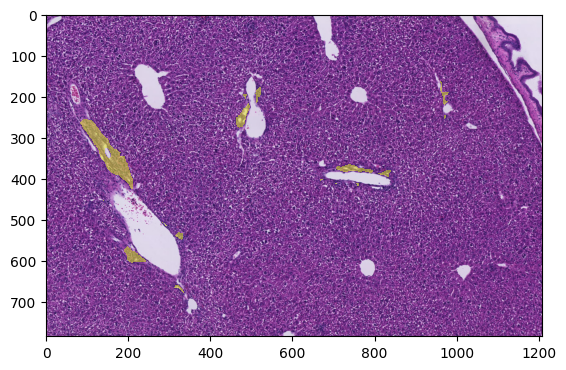

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from biliary_seg.data.image_loader import ImageLoader

image_loader = ImageLoader.from_data_dir(id='RG425_roi_0', data_dir='..\\data\\processed')

plt.imshow(image_loader.image)
mask = np.ma.masked_where(image_loader.mask == 0, image_loader.mask)
plt.imshow(mask, alpha=0.5, cmap='plasma_r')